# Indonesian Traffic Sign Detection - YOLOv8

Resizing dataset images to 1024x1024 pixels.

[link to my dataset]()

In [ ]:
import os
from PIL import Image, ExifTags

# Path asal dan tujuan
source_folder = r'D:\Perkuliahan\Semester 8\Skripsi\datasets\indonesian-traffic-sign-cam-1x1 (Balanced)'
target_folder = r'D:\Perkuliahan\Semester 8\Skripsi\datasets\indonesian-traffic-sign-cam-1x1 (Resized)'

# Cek apakah folder tujuan ada, jika tidak buat folder tersebut
if not os.path.exists(target_folder):
    os.makedirs(target_folder)
    print(f"Folder '{target_folder}' berhasil dibuat.")
else:
    print(f"Folder '{target_folder}' sudah ada.")

In [ ]:
# Loop all files in the source folder
for filename in os.listdir(source_folder):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.webp')):
        try:
            # Define image path
            img_path = os.path.join(source_folder, filename)

            # Check if the file already exists in the destination folder
            save_path = os.path.join(target_folder, filename)
            if os.path.exists(save_path):
                print(f"⏩ File {filename} already exists in the destination, skipping...")
                continue  # Skip if the file exists

            # Open image
            img = Image.open(img_path)

            # Fix image orientation if EXIF metadata is present
            try:
                exif = img._getexif()
                if exif is not None:
                    # Check for orientation in EXIF metadata
                    for tag, value in exif.items():
                        if ExifTags.TAGS.get(tag) == 'Orientation':
                            if value == 3:
                                img = img.rotate(180, expand=True)
                            elif value == 6:
                                img = img.rotate(270, expand=True)
                            elif value == 8:
                                img = img.rotate(90, expand=True)
                            break
            except (AttributeError, KeyError, IndexError):
                # No EXIF or no orientation
                pass

            # Resize image to 1200x1200
            img_resized = img.resize((1024, 1024), resample=Image.LANCZOS)

            # Save resized image to the destination folder
            img_resized.save(save_path)

            print(f"✅ Processed: {filename}")
        except Exception as e:
            print(f"❌ Error processing {filename}: {e}")

print("\n✅ All images have been successfully resized and copied.")

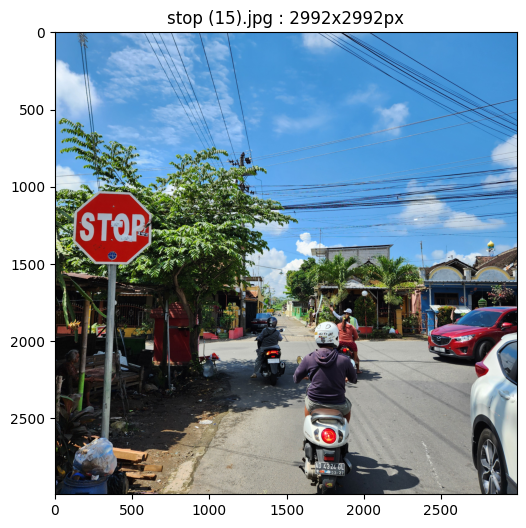

In [10]:
import matplotlib.pyplot as plt
import os
from PIL import Image, ExifTags

# Path to the image
img_path = r"E:\datasets - skripsi\preprocessing\indonesian-traffic-sign-cam-1x1\stop (15).jpg"  # Ganti dengan path gambar yang ingin ditampilkan

# Open the image
img = Image.open(img_path)

exif = img._getexif()
if exif is not None:
    # Check for orientation in EXIF metadata
    for tag, value in exif.items():
        if ExifTags.TAGS.get(tag) == 'Orientation':
            if value == 3:
                img = img.rotate(180, expand=True)
            elif value == 6:
                img = img.rotate(270, expand=True)
            elif value == 8:
                img = img.rotate(90, expand=True)
            break

# Get image dimensions
width, height = img.size

# Plot the image
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('on')  # Hide axes

# Show filename as title
plt.title(f"{os.path.basename(img_path)} : {width}x{height}px")
plt.show()
